In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, precision_recall_curve, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath('..'))
from src.lstm_encoder import HybridCNNBiLSTMEncoder
from src.fdi_classifier import TransferFDIClassifier

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Executing Phase 16 Main Experiment on: {device}")

# 1. Ingest Dataset B tensors (Phase 13 artifact)
data_path = Path('../data/processed_downstream/fdi_feeder_windows.npz')
data = np.load(data_path)

X_train, y_train = data['X_train'], data['y_train']
X_val, y_val     = data['X_val'],   data['y_val']
X_test, y_test   = data['X_test'],  data['y_test']

print(f"Data Loaded: Train={X_train.shape}, Val={X_val.shape}, Test={X_test.shape}")

train_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train).float().unsqueeze(1)),
    batch_size=64, shuffle=True, pin_memory=True
)
val_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val).float().unsqueeze(1)),
    batch_size=64, shuffle=False
)
test_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test).float().unsqueeze(1)),
    batch_size=64, shuffle=False
)

# Common Class Weight
num_neg = (y_train == 0).sum()
num_pos = (y_train == 1).sum()
pos_weight = torch.tensor([num_neg / num_pos], device=device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

Executing Phase 16 Main Experiment on: cuda
Data Loaded: Train=(5011, 30, 12), Val=(1051, 30, 12), Test=(1052, 30, 12)


In [2]:
class ScratchFDIModel(nn.Module):
    """Native 12-channel model trained purely from random initialization."""
    def __init__(self, in_channels=12, cnn_hidden_dims=(64, 128), lstm_hidden_dim=128, mlp_hidden_dim=64):
        super().__init__()
        self.encoder = HybridCNNBiLSTMEncoder(
            in_channels=in_channels,
            cnn_hidden_dims=cnn_hidden_dims,
            lstm_hidden_dim=lstm_hidden_dim,
            lstm_layers=2,
            pool_strategy="mean"
        )
        self.mlp_head = nn.Sequential(
            nn.Linear(self.encoder.out_dim, mlp_hidden_dim),
            nn.BatchNorm1d(mlp_hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(mlp_hidden_dim, 1)
        )

    def forward(self, x):
        h = self.encoder(x, return_sequence=False)
        return self.mlp_head(h)

# Instantiate and Train Model A (Scratch)
model_scratch = ScratchFDIModel().to(device)
optimizer_scratch = torch.optim.AdamW(model_scratch.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_scratch = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_scratch, mode='min', factor=0.5, patience=3)

EPOCHS = 25
best_val_f1_scratch = 0.0

print("\n--- Training Model A: From Scratch ---")
for epoch in range(1, EPOCHS + 1):
    model_scratch.train()
    running_loss = 0.0
    for x_b, y_b in train_loader:
        x_b, y_b = x_b.to(device), y_b.to(device)
        optimizer_scratch.zero_grad()
        logits = model_scratch(x_b)
        loss = criterion(logits, y_b)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_scratch.parameters(), max_norm=5.0)
        optimizer_scratch.step()
        running_loss += loss.item() * len(x_b)
    
    # Validation
    model_scratch.eval()
    val_loss, all_preds, all_targets = 0.0, [], []
    with torch.no_grad():
        for x_b, y_b in val_loader:
            x_b, y_b = x_b.to(device), y_b.to(device)
            logits = model_scratch(x_b)
            loss = criterion(logits, y_b)
            val_loss += loss.item() * len(x_b)
            preds = (torch.sigmoid(logits) >= 0.5).int().cpu().numpy()
            all_preds.extend(preds.flatten())
            all_targets.extend(y_b.cpu().numpy().flatten())
            
    val_loss /= len(val_loader.dataset)
    val_f1 = f1_score(all_targets, all_preds, zero_division=0)
    scheduler_scratch.step(val_loss)
    
    if val_f1 > best_val_f1_scratch:
        best_val_f1_scratch = val_f1
        torch.save(model_scratch.state_dict(), '../saved_models/exp_model_scratch_best.pth')

print(f"Model A (Scratch) Best Val F1: {best_val_f1_scratch*100:.2f}%")


--- Training Model A: From Scratch ---
Model A (Scratch) Best Val F1: 45.41%


In [3]:
# Model B is our fine-tuned transfer model from Phase 15
model_ssl = TransferFDIClassifier(
    in_channels=12,
    pretrained_channels=25,
    cnn_hidden_dims=(64, 128),
    lstm_hidden_dim=128,
    lstm_layers=2,
    mlp_hidden_dim=64,
    dropout=0.3,
    freeze_backbone=False
).to(device)

ssl_checkpoint = Path('../saved_models/fdi_finetuned_best.pth')
assert ssl_checkpoint.exists(), f"Phase 15 checkpoint not found at: {ssl_checkpoint}"

model_ssl.load_state_dict(torch.load(ssl_checkpoint, map_location=device, weights_only=True))
print(f"Loaded Model B (SSL Fine-Tuned) from: {ssl_checkpoint}")

Loaded Model B (SSL Fine-Tuned) from: ..\saved_models\fdi_finetuned_best.pth


In [4]:
def evaluate_model(model, loader):
    model.eval()
    probs, preds, targets = [], [], []
    with torch.no_grad():
        for x_b, y_b in loader:
            x_b = x_b.to(device)
            logits = model(x_b)
            p = torch.sigmoid(logits).cpu().numpy().flatten()
            pr = (p >= 0.5).astype(int)
            probs.extend(p)
            preds.extend(pr)
            targets.extend(y_b.numpy().flatten())
            
    probs = np.array(probs)
    preds = np.array(preds)
    targets = np.array(targets)
    
    return {
        'accuracy':  accuracy_score(targets, preds),
        'precision': precision_score(targets, preds, zero_division=0),
        'recall':    recall_score(targets, preds, zero_division=0),
        'f1':        f1_score(targets, preds, zero_division=0),
        'roc_auc':   roc_auc_score(targets, probs),
        'cm':        confusion_matrix(targets, preds),
        'probs':     probs,
        'preds':     preds,
        'targets':   targets
    }

# 1. Load best Model A (Scratch)
model_scratch.load_state_dict(torch.load('../saved_models/exp_model_scratch_best.pth', map_location=device, weights_only=True))

# 2. Run Holdout Test Evaluation
metrics_scratch = evaluate_model(model_scratch, test_loader)
metrics_ssl     = evaluate_model(model_ssl, test_loader)

# 3. Create Comparison DataFrame
comparison_df = pd.DataFrame({
    'Metric': ['Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'Accuracy'],
    'Model A (Scratch)': [
        f"{metrics_scratch['precision']*100:.2f}%",
        f"{metrics_scratch['recall']*100:.2f}%",
        f"{metrics_scratch['f1']*100:.2f}%",
        f"{metrics_scratch['roc_auc']*100:.2f}%",
        f"{metrics_scratch['accuracy']*100:.2f}%"
    ],
    'Model B (SSL Fine-Tuned)': [
        f"{metrics_ssl['precision']*100:.2f}%",
        f"{metrics_ssl['recall']*100:.2f}%",
        f"{metrics_ssl['f1']*100:.2f}%",
        f"{metrics_ssl['roc_auc']*100:.2f}%",
        f"{metrics_ssl['accuracy']*100:.2f}%"
    ]
})

print("=" * 65)
print("PHASE 16: MAIN THESIS BENCHMARK RESULTS")
print("=" * 65)
print(comparison_df.to_string(index=False))
print("=" * 65)

# Save Comparison CSV
results_dir = Path('../results')
results_dir.mkdir(parents=True, exist_ok=True)
comparison_df.to_csv(results_dir / 'phase16_main_experiment_comparison.csv', index=False)

PHASE 16: MAIN THESIS BENCHMARK RESULTS
   Metric Model A (Scratch) Model B (SSL Fine-Tuned)
Precision            57.45%                   20.36%
   Recall            25.71%                   53.33%
 F1-Score            35.53%                   29.47%
  ROC-AUC            73.04%                   53.40%
 Accuracy            81.37%                   49.05%


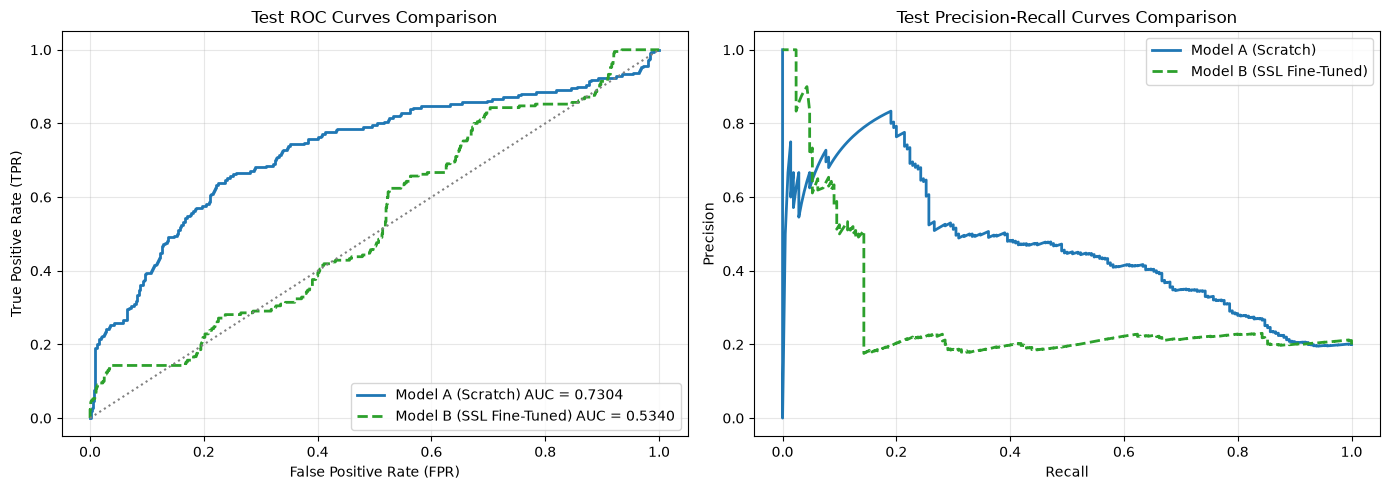

In [5]:
fig_dir = Path('../results/figures')
fig_dir.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Receiver Operating Characteristic (ROC) Curve
fpr_scratch, tpr_scratch, _ = roc_curve(metrics_scratch['targets'], metrics_scratch['probs'])
fpr_ssl, tpr_ssl, _         = roc_curve(metrics_ssl['targets'], metrics_ssl['probs'])

axes[0].plot(fpr_scratch, tpr_scratch, color='#1f77b4', lw=2,
             label=f"Model A (Scratch) AUC = {metrics_scratch['roc_auc']:.4f}")
axes[0].plot(fpr_ssl, tpr_ssl, color='#2ca02c', lw=2, linestyle='--',
             label=f"Model B (SSL Fine-Tuned) AUC = {metrics_ssl['roc_auc']:.4f}")
axes[0].plot([0, 1], [0, 1], color='grey', linestyle=':')
axes[0].set_title('Test ROC Curves Comparison')
axes[0].set_xlabel('False Positive Rate (FPR)')
axes[0].set_ylabel('True Positive Rate (TPR)')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# 2. Precision-Recall (PR) Curve
p_scratch, r_scratch, _ = precision_recall_curve(metrics_scratch['targets'], metrics_scratch['probs'])
p_ssl, r_ssl, _         = precision_recall_curve(metrics_ssl['targets'], metrics_ssl['probs'])

axes[1].plot(r_scratch, p_scratch, color='#1f77b4', lw=2, label="Model A (Scratch)")
axes[1].plot(r_ssl, p_ssl, color='#2ca02c', lw=2, linestyle='--', label="Model B (SSL Fine-Tuned)")
axes[1].set_title('Test Precision-Recall Curves Comparison')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(fig_dir / 'phase16_main_experiment_curves.png', dpi=300)
plt.show()